In [ ]:
# =========================================================
# 🍓 Strawberry Field Semantic-Aware CCPP
# YOLO成熟度監測後的智慧巡邏路徑規劃
#
# 功能：
# 1. 自動找出草莓區
# 2. 找出可通行通道
# 3. 只保留靠近草莓的通道
# 4. 建立 Coverage Path
# 5. 單一路徑只走一次
# 6. 自動避開障礙物
#
# 適合：
# Google Colab
# =========================================================

# =========================================================
# 安裝套件
# =========================================================
!pip install opencv-python-headless scikit-image networkx -q

Saving Screenshot_20260506_093931_Gallery.jpg to Screenshot_20260506_093931_Gallery.jpg
Image Size: (1440, 2574, 3)


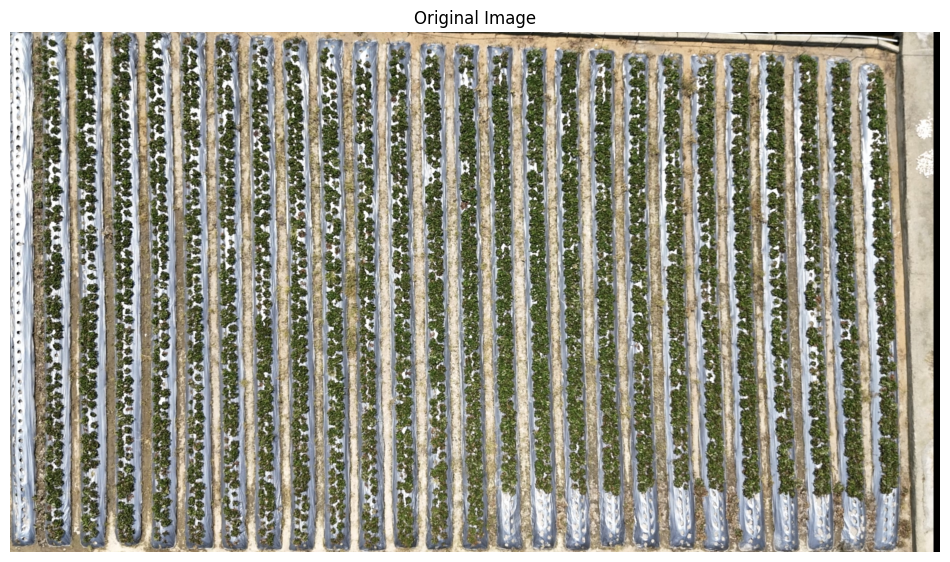

In [ ]:
# =========================================================
# import
# =========================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt

# =========================================================
# 上傳圖片
# =========================================================
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# =========================================================
# 讀取圖片
# =========================================================
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

H, W, _ = img.shape

print("Image Size:", img.shape)

# =========================================================
# 顯示原圖
# =========================================================
plt.figure(figsize=(12,12))
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

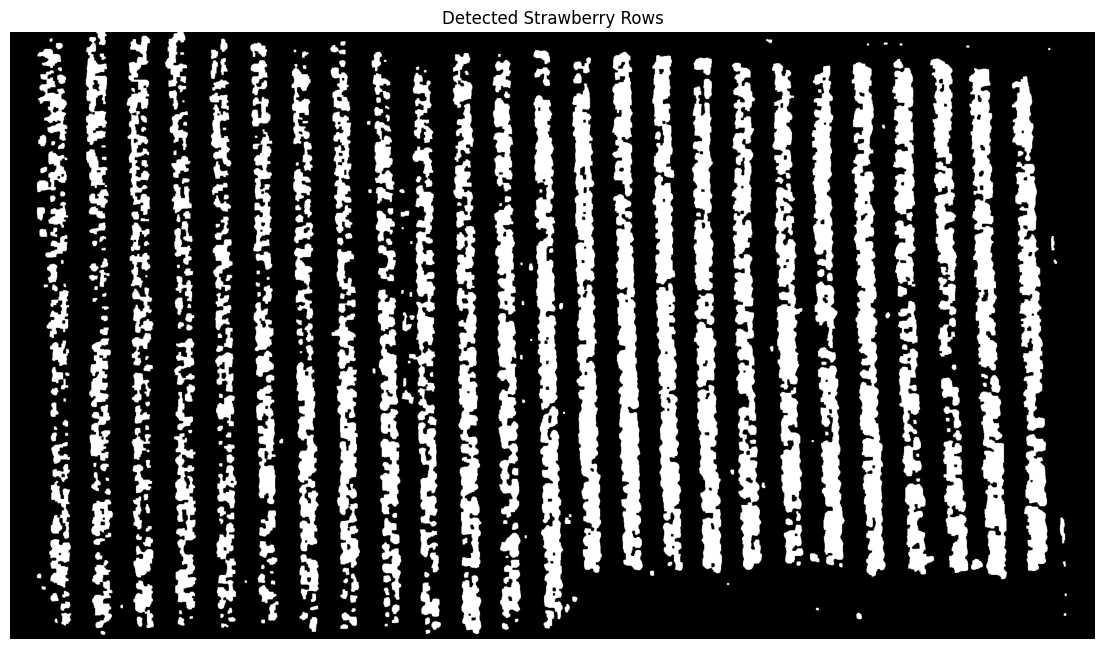

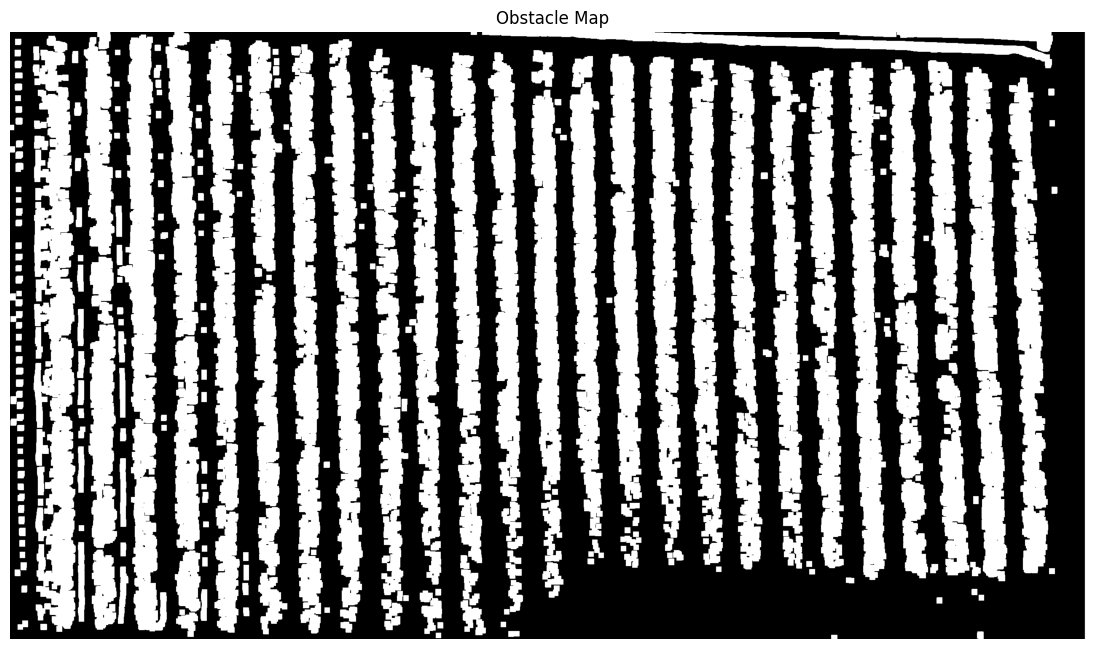

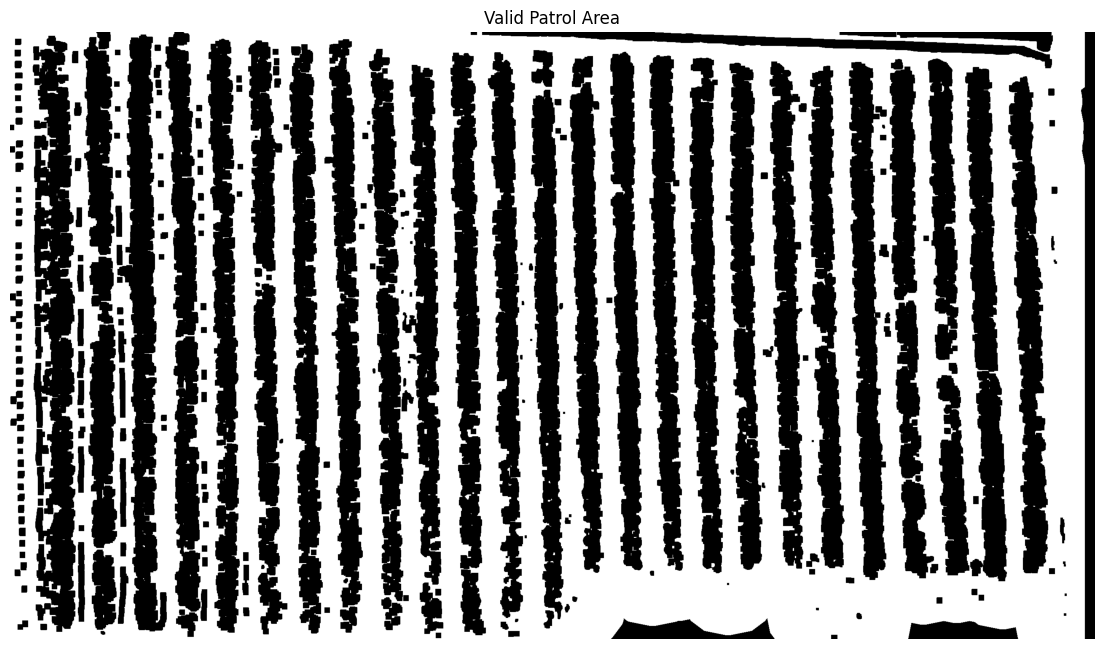

Detected Strawberry Rows: 25
Detected Corridors: 24
Coverage Path Length: 6649


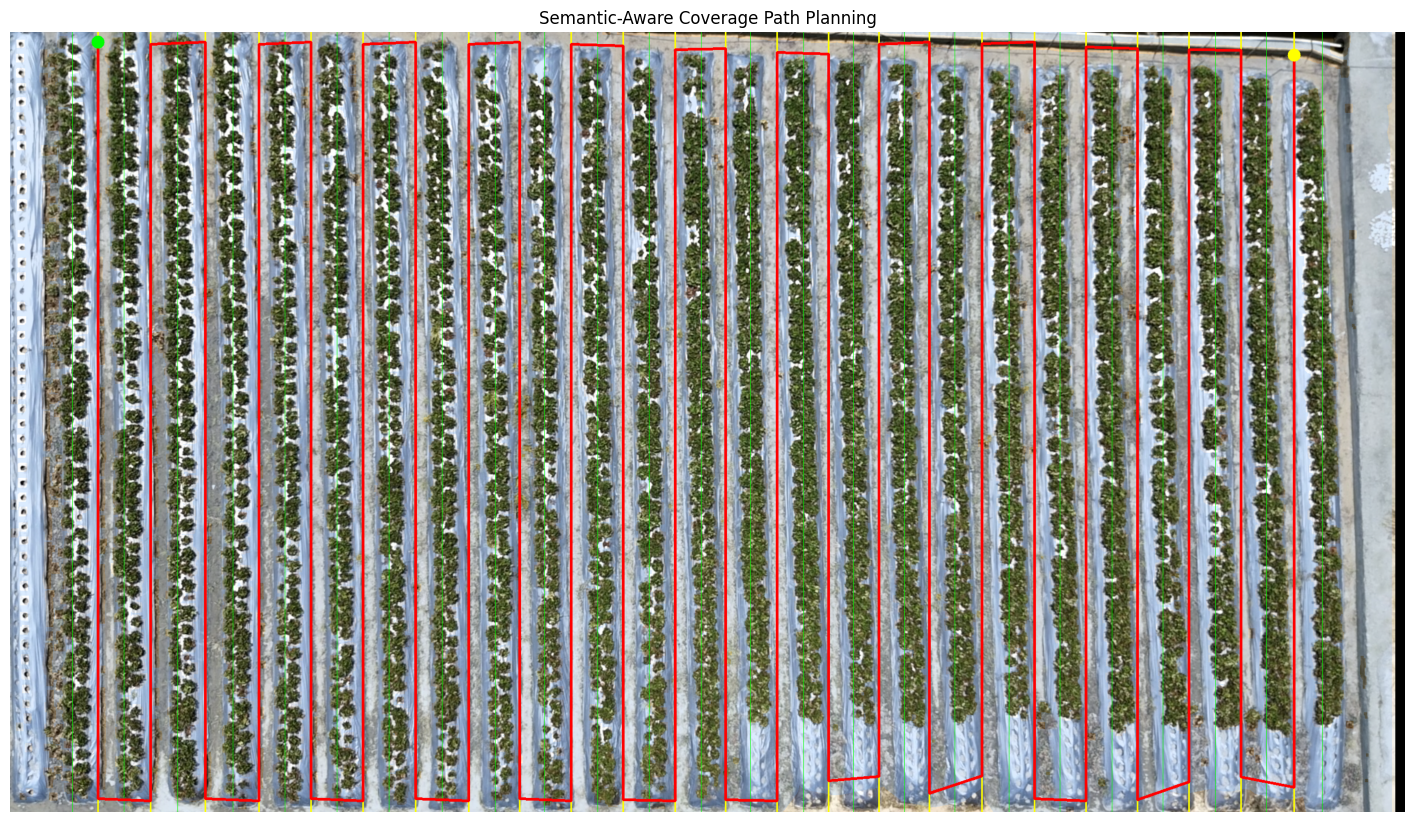

In [ ]:
# =========================================================
# HSV 色彩空間
# =========================================================
hsv = cv2.cvtColor(
    img,
    cv2.COLOR_RGB2HSV
)

# =========================================================
# Step 1：草莓區域偵測（綠色）
# =========================================================
lower_green = np.array([25, 40, 40])
upper_green = np.array([95, 255, 255])

green_mask = cv2.inRange(
    hsv,
    lower_green,
    upper_green
)

# =========================================================
# morphology 去除雜訊
# =========================================================
kernel = np.ones((5,5), np.uint8)

green_mask = cv2.morphologyEx(
    green_mask,
    cv2.MORPH_OPEN,
    kernel
)

green_mask = cv2.morphologyEx(
    green_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# =========================================================
# 顯示草莓區域
# =========================================================
plt.figure(figsize=(14,14))

plt.imshow(green_mask, cmap='gray')

plt.title("Detected Strawberry Rows")

plt.axis('off')

plt.show()

# =========================================================
# Step 2：建立可通行區域
# 非草莓區域
# =========================================================
walkable = 255 - green_mask

# =========================================================
# Step 3：障礙物偵測
# =========================================================
gray = cv2.cvtColor(
    img,
    cv2.COLOR_RGB2GRAY
)

# 深色區域
_, obstacle = cv2.threshold(
    gray,
    55,
    255,
    cv2.THRESH_BINARY_INV
)

# 膨脹障礙物
obstacle = cv2.dilate(
    obstacle,
    kernel,
    iterations=3
)

# 移除障礙物
walkable[obstacle > 0] = 0

# =========================================================
# 顯示障礙物
# =========================================================
plt.figure(figsize=(14,14))

plt.imshow(obstacle, cmap='gray')

plt.title("Obstacle Map")

plt.axis('off')

plt.show()

# =========================================================
# Step 4：只保留靠近草莓的區域
# =========================================================
dist = cv2.distanceTransform(
    255 - green_mask,
    cv2.DIST_L2,
    5
)

# 距離閾值
NEAR_THRESHOLD = 120

near_strawberry = dist < NEAR_THRESHOLD

# 有效巡邏區域
valid = np.logical_and(
    walkable > 0,
    near_strawberry
)

valid = valid.astype(np.uint8) * 255

# =========================================================
# 顯示有效區域
# =========================================================
plt.figure(figsize=(14,14))

plt.imshow(valid, cmap='gray')

plt.title("Valid Patrol Area")

plt.axis('off')

plt.show()

# =========================================================
# Step 5：草莓列偵測
# =========================================================

# 每個 column 的綠色像素數量
green_column_sum = np.sum(
    green_mask > 0,
    axis=0
)

# =========================================================
# 找出草莓列
# =========================================================
GREEN_THRESHOLD = H * 0.25

green_cols = np.where(
    green_column_sum > GREEN_THRESHOLD
)[0]

# =========================================================
# 合併連續草莓列
# =========================================================
rows = []

start = green_cols[0]

for i in range(1, len(green_cols)):

    # 如果 column 間隔變大
    if green_cols[i] - green_cols[i-1] > 10:

        end = green_cols[i-1]

        center = (start + end) // 2

        rows.append(center)

        start = green_cols[i]

# 最後一列
end = green_cols[-1]

center = (start + end) // 2

rows.append(center)

print("Detected Strawberry Rows:", len(rows))

# =========================================================
# Step 6：建立通道中心
# 通道 = 兩列草莓中間
# =========================================================
corridors = []

for i in range(len(rows)-1):

    left_row = rows[i]
    right_row = rows[i+1]

    # =====================================================
    # 通道中心
    # =====================================================
    corridor_x = (left_row + right_row) // 2

    # =====================================================
    # 過濾太窄通道
    # =====================================================
    if right_row - left_row < 25:
        continue

    # =====================================================
    # 必須有足夠有效區域
    # =====================================================
    valid_pixels = np.sum(
        valid[:, corridor_x] > 0
    )

    if valid_pixels < H * 0.35:
        continue

    # =====================================================
    # 垂直方向完整度
    # 避免房子附近破碎通道
    # =====================================================
    column_valid_ratio = np.mean(
        valid[:, corridor_x] > 0
    )

    if column_valid_ratio < 0.35:
        continue

    corridors.append(corridor_x)

print("Detected Corridors:", len(corridors))

# =========================================================
# Step 7：Coverage Path Planning
# Zigzag Coverage
# =========================================================
path = []

direction = 1

STEP_SIZE = 5

for x in corridors:

    ys = np.where(
        valid[:, x] > 0
    )[0]

    # 通道太短跳過
    if len(ys) < 100:
        continue

    y_top = np.min(ys)
    y_bottom = np.max(ys)

    # =====================================================
    # 安全邊界
    # =====================================================
    TOP_SAFE_MARGIN = 20
    BOTTOM_SAFE_MARGIN = 20

    y_top += TOP_SAFE_MARGIN
    y_bottom -= BOTTOM_SAFE_MARGIN

    # =====================================================
    # Zigzag Coverage
    # =====================================================
    if direction == 1:

        for y in range(
            y_top,
            y_bottom,
            STEP_SIZE
        ):

            path.append((x, y))

    else:

        for y in range(
            y_bottom,
            y_top,
            -STEP_SIZE
        ):

            path.append((x, y))

    direction *= -1

print("Coverage Path Length:", len(path))

# =========================================================
# Step 8：建立結果圖
# =========================================================
result = img.copy()

# =========================================================
# 有效區域疊圖
# =========================================================
overlay = result.copy()

overlay[valid > 0] = [120, 180, 255]

ALPHA = 0.25

result = cv2.addWeighted(
    overlay,
    ALPHA,
    result,
    1 - ALPHA,
    0
)

# =========================================================
# 畫草莓列中心
# =========================================================
for row_x in rows:

    cv2.line(
        result,
        (row_x, 0),
        (row_x, H),
        (0,255,0),
        1
    )

# =========================================================
# 畫通道中心
# =========================================================
for corridor_x in corridors:

    cv2.line(
        result,
        (corridor_x, 0),
        (corridor_x, H),
        (255,255,0),
        2
    )

# =========================================================
# 畫 Coverage Path
# =========================================================
for i in range(1, len(path)):

    x1, y1 = path[i-1]
    x2, y2 = path[i]

    cv2.line(
        result,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

# =========================================================
# 起點
# =========================================================
sx, sy = path[0]

cv2.circle(
    result,
    (sx, sy),
    12,
    (0,255,0),
    -1
)

# =========================================================
# 終點
# =========================================================
ex, ey = path[-1]

cv2.circle(
    result,
    (ex, ey),
    12,
    (255,255,0),
    -1
)

# =========================================================
# 顯示結果
# =========================================================
plt.figure(figsize=(18,18))

plt.imshow(result)

plt.title("Semantic-Aware Coverage Path Planning")

plt.axis('off')

plt.show()
